# Halo at LUXE's IP

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd

import plotXsuite
from scipy.special import erf

from manchester_farm.background import beamGas

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_06_29"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Halo/" + date + "_EuXFEL_plot"

In [2]:
def plotExpectedHits(xsuite, linename, gmadfilename, histfilename=None, gmadfolder='gmad_files/',
                     emitx=3.58e-11, emity=3.58e-11, esprd=2e-6,
                     pipe_radius=0.02413, ngen=500_000,
                     xlabel=True, xlim=None, ylim=None, lattice=True, figsize=[12, 3]):
    line = xsuite.env.lines[linename]
    tws0 = xsuite.tws0
    s0 = xsuite.s0
    _plt.figure(figsize=figsize)
    tw = line.twiss(**tws0)
    E0 = tw.particle_on_co.p0c.base
    sigx = _np.sqrt(tw.betx * emitx + tw.dx ** 2 * (esprd / E0) ** 2)
    sigy = _np.sqrt(tw.bety * emity + tw.dy ** 2 * (esprd / E0) ** 2)

    n_sigma_x = pipe_radius / sigx
    n_sigma_y = pipe_radius / sigy

    proba_x = 0.5*(1 - erf(n_sigma_x / _np.sqrt(2)))
    proba_y = 0.5*(1 - erf(n_sigma_y / _np.sqrt(2)))

    hit_x = proba_x * ngen
    hit_y = proba_y * ngen
    hits = hit_x + hit_y
    
    if histfilename is not None:
        histfile = _bd.Data.Load(histfilename)
        hist = histfile.histogramspy["Event/MergedHistograms/" + 'PFH_S_all']
        beamGas.plotHistogram(histfilename, "PFH_S_all", gmadfile=None, samefig=True, s0=s0, label='PFH_S_all : {} hits'.format(hist.entries))
    _plt.hist(tw.s + s0, bins=200, weights=hits, histtype='step', color="C1", label=r'Expected : {:.2f} hits'.format(sum(hits)))
    # _plt.plot(tw.s + s0, hits, ls='', marker='+', markersize=10, color='C1', label=r'Expected hits')
    

    _plt.ylabel(r'$N_{{hit}}$')
    if xlabel:
        _plt.xlabel(r'$s$ [m]')
    _plt.grid(True)
    _plt.legend(loc='upper right')
    _plt.ylim(ylim)
    if lattice:
        plotXsuite.addMachineLattice(xsuite, linename, gmadfilename, gmadfolder)
    _plt.xlim(xlim)

In [195]:
from scipy.integrate import quad
from scipy.stats import norm

def gauss(x, mu=0, sigma=0.1, c=1):
    A = c/(_np.sqrt(2*_np.pi)*sigma)
    return A*_np.exp(-(x-mu)**2/(2*sigma**2))

def probaGauss(x_min=-1000, x_max=0, mu=0, sigma=0.1):
    X = _np.linspace(x_min, x_max, 1000000)
    f = lambda x: gauss(x, mu=mu, sigma=sigma)
    Y = gauss(X, sigma=sigma)
    area = _np.trapz(Y, X)
    result, error = quad(f, x_min, x_max)
    return result, error

def gaussian_integral(a, b, mu=0.0, sigma=1.0):
    return norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)

In [252]:
ngen = 100_000
beta = 158
# emit = 3.58e-11
emit = 2.5e-7
sigma = _np.sqrt(beta*emit)
x_min = 0.02413
x_max = _np.inf
gaussian_integral(x_min, x_max, sigma=sigma)

np.float64(6.167785989674712e-05)

In [253]:
x_min = 4.5*sigma
x_max = 5.5*sigma
gaussian_integral(x_min, x_max, sigma=sigma)

np.float64(3.378683562260676e-06)

In [213]:
2 * norm.cdf(-0.02413, loc=0, scale=sigma) * ngen

np.float64(12.335571979343447)

In [173]:
sigma = 75e-6
x_min = 4.5*sigma
x_max = 5.5*sigma
# x_min = 0.02413
# x_max = 1000
2 * probaGauss(x_min=x_min, x_max=x_max, sigma=sigma)

np.float64(21311676120883.426)

In [75]:
X = _np.linspace(-0.5, 0.5, 200)
Y = gauss(X, c=1e-1)

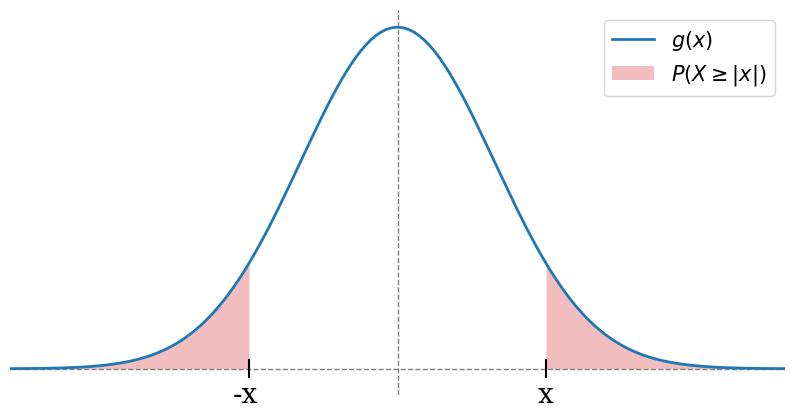

In [250]:
_plt.figure(figsize=[10, 5])
_plt.axhline(0, ls='--', color='gray', lw=1)
_plt.axvline(0, ls='--', color='gray', lw=1)
_plt.plot(X, Y, lw=2, color='C0', label=r"$g(x)$")
mask = (X >= -0.5) & (X <= -0.15)
_plt.fill_between(X[mask], Y[mask], alpha=0.3, lw=0, color='C3', label=r"$P(X \geq |x|)$")
mask = (X <= 0.5) & (X >= 0.15)
_plt.fill_between(X[mask], Y[mask], alpha=0.3, lw=0, color='C3')

# _plt.arrow(x=0, y=0, dx=0, dy=0.1, width=0.001, color='k', head_width=0.01, head_length=0.02, overhang=0.2)
# _plt.arrow(x=0, y=0, dx=0.08, dy=0, width=0.001, color='k', head_width=0.01, head_length=0.02, overhang=0.2)
# _plt.text(0.08, 0.02, 'x', fontname='serif')
# _plt.text(-0.03, 0.1, 'y', fontname='serif')

_plt.plot([0.153, 0.153], [-0.01, 0.01], color='k')
_plt.plot([-0.153, -0.153], [-0.01, 0.01], color='k')
_plt.text(0.145, -0.04, 'x', fontname='serif', fontsize=20)
_plt.text(-0.17, -0.04, '-x', fontname='serif', fontsize=20)

_plt.xlim([-0.4, 0.4])
_plt.legend()
_plt.axis('off')

os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
_plt.savefig("{}_Example_halo.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

In [23]:
_np.sqrt(2.5*157)

np.float64(0.006264982043070834)

In [156]:
0.5*(1-erf(0.02413/(_np.sqrt(2)*6.26e-3)))

np.float64(5.7951778797360465e-05)

In [29]:
0.02413/(_np.sqrt(2)*75e-6)

np.float64(227.4998217337519)

In [3]:
from xsuite_scripts import XTD8_no_DBA_match_with_no_R56 as XTD8_matched_Xsuite

In [3]:
mergedhistfile = "manchester_farm/background/results/mergedfiles/1985000_part_XTD8_halo_4.5-5.5_emit_2.5e-7_merged.root"

REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


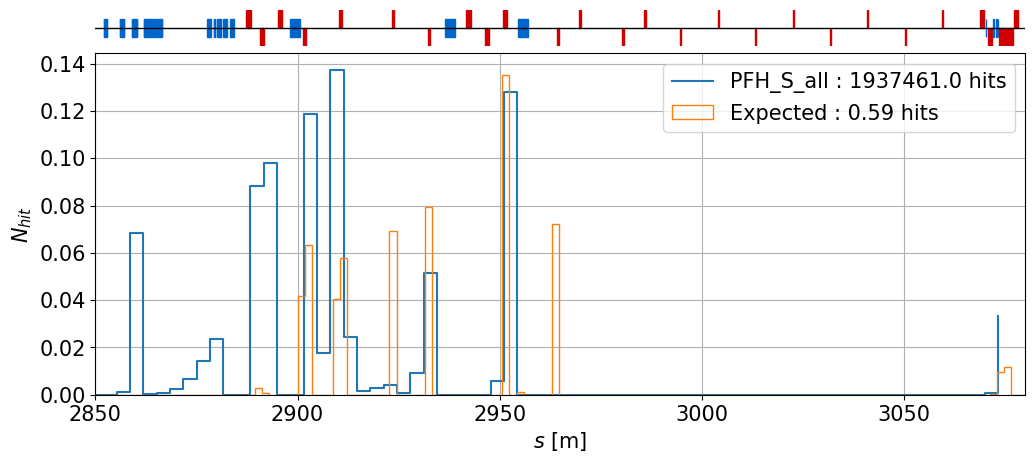

In [14]:
plotExpectedHits(XTD8_matched_Xsuite, 'XTD8', "XTD8_matched_biasing", mergedhistfile,
                 emitx=2.5e-7, emity=2.5e-7, esprd=0, ngen=1_000,
                 figsize=[12, 5], lattice=True, 
                 # xlim=[2900, 2970]
                 xlim=[2850, 3080]
                )

REBDSIMCOMBINE analysis file - using RebdsimFile


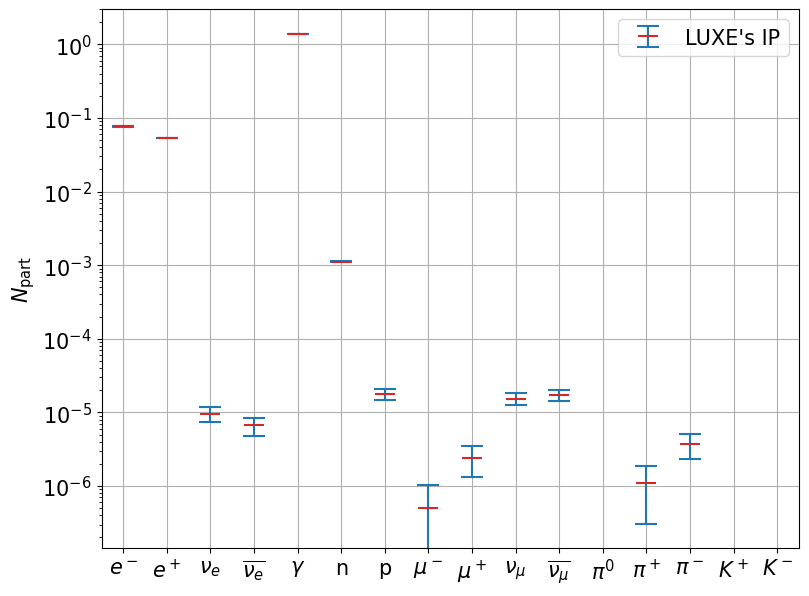

In [4]:
beamGas.plotHistogram(mergedhistfile, "D2890L_partID",
                      errorbars=True, partlabels=True, logY=True, xlim=[0.5, 16.5], samefig=False, 
                      figsize=[9, 7])
_plt.legend(["LUXE's IP"])
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
_plt.savefig("{}_Particle_species_halo_at_LUXE_IP.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

In [8]:
def calcHowMuchSigma(pipe_radius = 0.02413, emittance=2e-7, beta=160, disp=-2, sigmaE=0.0006, E0=17.5):
    sigma = _np.sqrt(beta*emittance + disp**2 * sigmaE**2 / E0**2)
    return pipe_radius / sigma

def estimateHits(primaries=100_000, pipe_radius = 0.02413, emittance=2e-7, beta=160, disp=-2, sigmaE=0.0006, E0=17.5):
    # get at how much sigma is the beam pipe
    n_sigma = calcHowMuchSigma(pipe_radius, emittance, beta, disp, sigmaE, E0)
    
    # get the probability of a particle ot be hitting th pipe
    proba = 1 - erf(n_sigma/_np.sqrt(2))
    
    return proba * primaries

In [13]:
calcHowMuchSigma(pipe_radius = 0.02413, emittance=2.5e-7, beta=160, disp=0, sigmaE=0, E0=17.5)

np.float64(3.8152879969931495)

BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


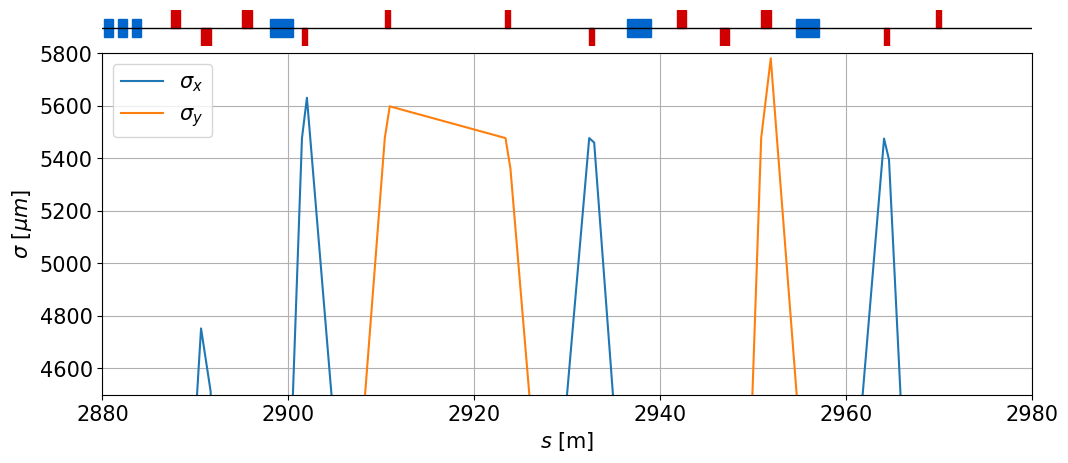

In [21]:
plotXsuite.plotSigma(XTD8_matched_Xsuite, 'XTD8', "XTD8_matched_biasing", emitx=2e-7, emity=2e-7, esprd=0, 
                     figsize=[12, 5], lattice=True, markers=False, xlim=[2880, 2980], ylim=[4500, 5800])
# _plt.axhline(0.02413*2*1e6, ls='--', color='k')